# 绘制轨迹

In [1]:
import numpy as np
import os
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.utils.data as Data
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from tqdm import trange, tqdm
from scipy.optimize import minimize
from matplotlib import rcParams

import csv
import pandas as pd


import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
torch.set_default_tensor_type('torch.DoubleTensor')
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataset import random_split
from tqdm import trange, tqdm
from matplotlib import rcParams
import sys
if sys.platform == 'win32':
    NUM_WORKERS = 0 # Windows does not support multiprocessing
else:
    NUM_WORKERS = 2

config = {
        "font.family":'Times New Roman',
        "font.size": 6,
}
rcParams.update(config)
np.random.seed(42)

os.environ['KMP_DUPLICATE_LIB_OK']='True'

c:\Users\lnz113\.conda\envs\D_learning\Lib\site-packages\torch\__init__.py:1236: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\tensor\python_tensor.cpp:436.)
  _C._set_default_tensor_type(t)


In [2]:
import numpy as np
import os
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.utils.data as Data
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from tqdm import trange, tqdm
from scipy.optimize import minimize
from matplotlib import rcParams

import csv
import pandas as pd


import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
torch.set_default_tensor_type('torch.DoubleTensor')
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataset import random_split
from tqdm import trange, tqdm
from matplotlib import rcParams
import sys
if sys.platform == 'win32':
    NUM_WORKERS = 0 # Windows does not support multiprocessing
else:
    NUM_WORKERS = 2

config = {
        "font.family":'Times New Roman',
        "font.size": 6,
}
rcParams.update(config)
np.random.seed(42)

os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [3]:
test_index = [17, 19, 22, 24, 27, 29, 32, 34, 37, 39,42, 47, 52]

绘制伺服精度收敛曲线，特征收敛曲线，速度变化曲线，以及与PBVS的轨迹对比

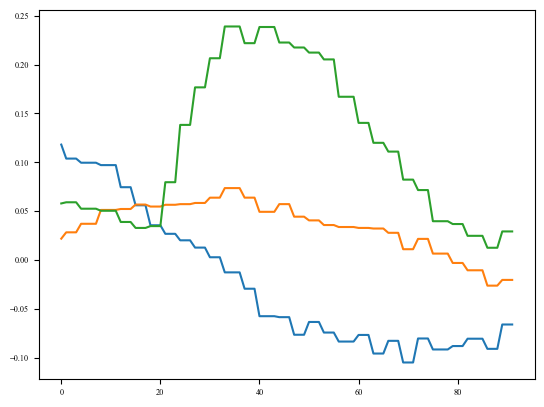

In [4]:
stateData_all = []

for i in test_index:
    filename = './flight_data_0219/cwp_dataengine_{}.csv'.format(str(i))
    stateDataAll1 = np.loadtxt(open(filename,"rb"),delimiter=",",skiprows=1)
    delta_uv = stateDataAll1[:,9:12] # 无人机数据集的图像跟踪误差
    # 读取每条拦截数轨迹的起始时间戳
    # 通过对初始时间戳做差求解无人机到达数据点经过的时间
    # 最终将经过处理的数据轨迹添加到训练集
    t = stateDataAll1[0,16]
    for i in range(len(stateDataAll1)):
        stateDataAll1[i,16] = stateDataAll1[i,16] - t
#         if np.abs(delta_uv[i,0]) < 0.5 and np.abs(delta_uv[i,1]) < 0.5:
#             print("change data!")
#             stateDataAll1[i,3] = 0.0
#             stateDataAll1[i,4] = 0.0
#             stateDataAll1[i,5] = 0.0
    stateData_all.append(stateDataAll1)
    # print(stateDataAll1.shape)
_ = plt.plot(stateData_all[1][:,3:6])

In [5]:
ts_mean_list = []
for j in range(len(test_index)):
    ts_mean = 0.0
    # stateData_all[j][:,23:25] = stateData_all[j][:,23:25] / 185.0
    for i in range(len(stateData_all[j])-1):
        ts_mean += stateData_all[j][:,16][i+1] - stateData_all[j][:,16][i]
    ts_mean = ts_mean / (len(stateData_all[j])-1)
    # print(ts_mean)
    ts_mean_list.append(ts_mean)

# 第三条轨迹的数组维度
print((stateData_all[2].shape))
print(np.mean(np.array(ts_mean_list)))

stateDataAll = stateData_all[0]
for j in trange(len(test_index)-1):
    j = j+1
    stateDataAll = np.vstack((stateDataAll,stateData_all[j]))
print((stateDataAll.shape))


(146, 49)
0.03332531874694523


100%|██████████| 12/12 [00:00<?, ?it/s]

(1438, 49)


In [6]:
import csv
stateData_all1 = []

import os

path = "./flight_data_metric_0221"

files= os.listdir(path)
files = sorted(files,key=lambda x: os.path.getmtime(os.path.join(path, x)))
min_distance_list = []
j=0
sum=0

for file in files:
    stateDataAll = np.loadtxt(open(path+"/"+file,"rb"),delimiter=",",skiprows=1)
    t = stateDataAll[0,19]
    for i in range(len(stateDataAll)):
        # print(stateDataAll[i,12])
        stateDataAll[i,19] = stateDataAll[0,19] - t
        if np.abs(stateDataAll[i,12]) < 1.5 and np.abs(stateDataAll[i,13]) < 1.5:
            stateData_all1.append(stateDataAll)
            sum= sum+1
            break

对2轨迹进行绘制

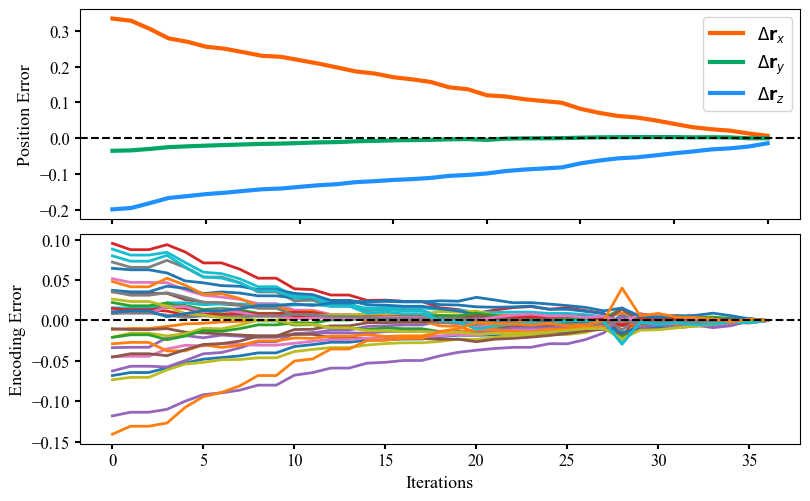

In [8]:
import scipy.signal as ss
import matplotlib.pyplot as plt
import numpy as np

# 初始化滤波器参数
b, a = ss.butter(3, 0.2)

# 创建图像
fig = plt.figure(figsize=(8, 5))

# 假设 stateData_all1 是一个包含数据的列表
j = 2
uavPosNED = stateData_all1[j][25:, 0:3]
uavVelNED = stateData_all1[j][25:, 3:6]
uavAngEular = stateData_all1[j][25:, 6:9]
delta_uv = stateData_all1[j][25:, 9:12]
control_rc = stateData_all1[j][25:, 15:18]
timestamp = stateData_all1[j][25:, 19]
vae_code = stateData_all1[j][25:, 20:20+32]
vae_code_d = stateData_all1[j][-1, 20:20+32]
vae_code = vae_code - vae_code_d

# 计算位置误差
b1 = uavPosNED[:-1, :] - uavPosNED[-1, :]

# 创建子图 ax2 和 ax1
ax2 = fig.add_subplot(2, 1, 2)
ax2.plot(vae_code[:], linewidth=2)
ax2.axhline(y=0, color='k', linestyle='--')
ax2.set_ylabel('Encoding Error', fontdict={'family': 'Times New Roman', 'size': 13})
ax2.set_xlabel('Iterations', fontdict={'family': 'Times New Roman', 'size': 13})
ax2.tick_params(axis='both', labelsize=12, width=1.5)  # 坐标轴数字变粗

ax1 = fig.add_subplot(2, 1, 1)
ax1.plot(b1[:, 0], label=r'$\Delta \mathbf{r}_x$', linewidth=3, color='#FF6100')
ax1.plot(b1[:, 1], label=r'$\Delta \mathbf{r}_y$', linewidth=3, color='#00A664')
ax1.plot(b1[:, 2], label=r'$\Delta \mathbf{r}_z$', linewidth=3, color='#1E90FF')
ax1.axhline(y=0, color='k', linestyle='--')
ax1.legend(fontsize ='12')
ax1.set_ylabel('Position Error', fontdict={'family': 'Times New Roman', 'size': 13})
ax1.tick_params(axis="x", labelbottom=False)
ax1.tick_params(axis='both', labelsize=12, width=1.5)  # 坐标轴数字变粗

# 调整布局并保存图像
plt.tight_layout()
plt.savefig('real_fig2.png', dpi=300)
plt.show()

MovieWriter imagemagick unavailable; using Pillow instead.


uavPosNED shape: (37, 3)
vae_code shape: (37, 32)
b1 shape: (36, 3)
timestamp shape: (37,)
b1 min/max: -0.1975550651550293 0.33361248672008514
vae_code min/max: -0.14075066894292831 0.09549063444137573


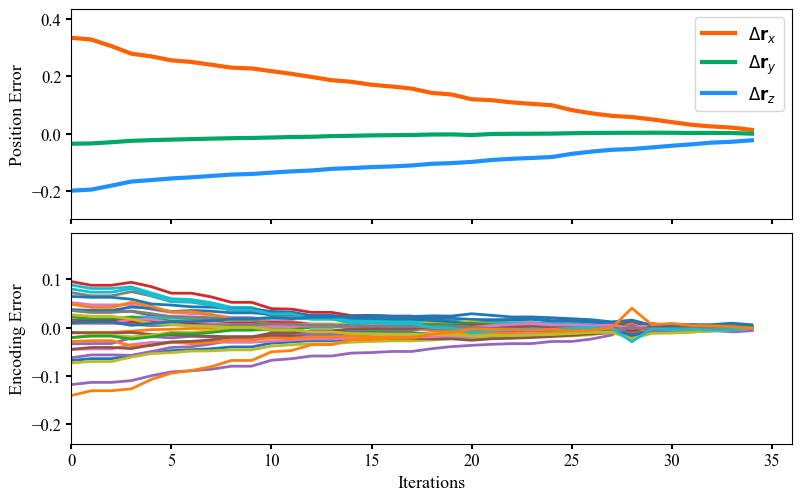

In [9]:
import scipy.signal as ss
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.animation as animation

# 初始化滤波器参数
b, a = ss.butter(3, 0.2)

# 创建图像
fig = plt.figure(figsize=(8, 5))

# 假设 stateData_all1 是一个包含数据的列表
j = 2
uavPosNED = stateData_all1[j][25:, 0:3]
uavVelNED = stateData_all1[j][25:, 3:6]
uavAngEular = stateData_all1[j][25:, 6:9]
delta_uv = stateData_all1[j][25:, 9:12]
control_rc = stateData_all1[j][25:, 15:18]
timestamp = stateData_all1[j][25:, 19]
vae_code = stateData_all1[j][25:, 20:20+32]
vae_code_d = stateData_all1[j][-1, 20:20+32]
vae_code = vae_code - vae_code_d

# 计算位置误差
b1 = uavPosNED[:-1, :] - uavPosNED[-1, :]

# 打印数据形状
print("uavPosNED shape:", uavPosNED.shape)
print("vae_code shape:", vae_code.shape)
print("b1 shape:", b1.shape)
print("timestamp shape:", timestamp.shape)

# 确保 b1 和 vae_code 的长度一致
min_length = min(len(b1), len(vae_code))
b1 = b1[:min_length]
vae_code = vae_code[:min_length]

# 打印数据范围
print("b1 min/max:", np.min(b1), np.max(b1))
print("vae_code min/max:", np.min(vae_code), np.max(vae_code))

# 创建子图 ax2 和 ax1
ax2 = fig.add_subplot(2, 1, 2)
ax2.set_ylabel('Encoding Error', fontdict={'family': 'Times New Roman', 'size': 13})
ax2.set_xlabel('Iterations', fontdict={'family': 'Times New Roman', 'size': 13})
ax2.tick_params(axis='both', labelsize=12, width=1.5)  # 坐标轴数字变粗

ax1 = fig.add_subplot(2, 1, 1)
ax1.set_ylabel('Position Error', fontdict={'family': 'Times New Roman', 'size': 13})
ax1.tick_params(axis="x", labelbottom=False)
ax1.tick_params(axis='both', labelsize=12, width=1.5)  # 坐标轴数字变粗

# 初始化空的线对象
line1, = ax1.plot([], [], label=r'$\Delta \mathbf{r}_x$', linewidth=3, color='#FF6100')
line2, = ax1.plot([], [], label=r'$\Delta \mathbf{r}_y$', linewidth=3, color='#00A664')
line3, = ax1.plot([], [], label=r'$\Delta \mathbf{r}_z$', linewidth=3, color='#1E90FF')

# 初始化编码误差图的线对象
lines_vae = [ax2.plot([], [], linewidth=2, label=f'Dim {i}')[0] for i in range(vae_code.shape[1])]

# 添加图例
ax1.legend(fontsize='12')

# 设置坐标轴范围（固定范围）
ax1.set_xlim(0, min_length)
ax1.set_ylim(np.min(b1) - 0.1, np.max(b1) + 0.1)  # 根据数据范围设置 y 轴范围
ax2.set_xlim(0, min_length)
ax2.set_ylim(np.min(vae_code) - 0.1, np.max(vae_code) + 0.1)  # 根据数据范围设置 y 轴范围

# 初始化函数，设置初始状态
def init():
    line1.set_data([], [])
    line2.set_data([], [])
    line3.set_data([], [])
    for line in lines_vae:
        line.set_data([], [])
    return [line1, line2, line3] + lines_vae

# 更新函数，用于每一帧的更新
def update(frame):
    # 更新位置误差图
    x_data = np.arange(frame)
    line1.set_data(x_data, b1[:frame, 0])
    line2.set_data(x_data, b1[:frame, 1])
    line3.set_data(x_data, b1[:frame, 2])
    
    # 更新编码误差图（绘制所有列）
    for i, line in enumerate(lines_vae):
        line.set_data(x_data, vae_code[:frame, i])
    
    return [line1, line2, line3] + lines_vae

# 计算帧数
total_frames = min_length
frame_rate = total_frames / 7.31  # 根据总时间计算帧率

# 创建动画
ani = animation.FuncAnimation(fig, update, frames=total_frames, init_func=init, blit=True, interval=1000/frame_rate)

# 保存动画为GIF
ani.save('real_fig2_animation.gif', writer='imagemagick', fps=frame_rate)

# 显示动画
plt.tight_layout()
plt.show()